# Train a Language Model from Scratch

## Table of Contents
1. Environment Setup
2. Dataset Acquisition & Exploration
3. Tokenization (BPE from Scratch + Production)
4. Model Architecture from Scratch
5. Training Pipeline
6. PyTorch MPS vs MLX Comparison
7. Evaluation & Generation
8. Putting It All Together

---
# Part 1: Environment Setup

In [34]:
# Install required packages (run once)
# Uncomment and run if packages are not installed

# !pip install torch torchvision torchaudio
# !pip install mlx mlx-lm
# !pip install datasets tiktoken tokenizers sentencepiece
# !pip install numpy pandas matplotlib tqdm
# !pip install wandb  # Optional: experiment tracking

In [1]:
# Core imports
import os
import sys
import math
import json
import time
import pickle
from pathlib import Path
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict

# Numerical computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")

Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:23:37) [Clang 14.0.6 ]
PyTorch version: 2.10.0


In [2]:
# ============================================================
# Framework Selection (configure this at the start)
# ============================================================
# Choose which backend to use for training + inference wrappers:
#   - 'mlx'     : Apple MLX backend (recommended on Apple Silicon when available)
#   - 'pytorch' : PyTorch backend (uses MPS on Apple Silicon if available)
#   - 'auto'    : use MLX if available, otherwise PyTorch

TRAINING_FRAMEWORK = 'mlx'  # <-- change to 'mlx' or 'pytorch'
print(f"Training framework preference: {TRAINING_FRAMEWORK}")


Training framework preference: mlx


In [3]:
# Verify MPS (Metal Performance Shaders) availability
print("=" * 50)
print("PyTorch MPS Backend Check")
print("=" * 50)

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    print(f"MPS is available!")
    print(f"MPS device: {mps_device}")
    
    # Test MPS with a simple operation
    x = torch.randn(1000, 1000, device=mps_device)
    y = torch.matmul(x, x)
    print(f"MPS test passed: matrix multiplication on {x.shape}")
else:
    print("MPS is NOT available")
    if torch.backends.mps.is_built():
        print("MPS is built but not available (check macOS version)")
    mps_device = torch.device("cpu")

# Set default device
DEVICE = mps_device if torch.backends.mps.is_available() else torch.device("cpu")
print(f"\nUsing device: {DEVICE}")

PyTorch MPS Backend Check
MPS is available!
MPS device: mps
MPS test passed: matrix multiplication on torch.Size([1000, 1000])

Using device: mps


In [4]:
# Verify MLX availability
print("=" * 50)
print("MLX Framework Check")
print("=" * 50)

try:
    import mlx.core as mx
    import mlx.nn as mlx_nn
    import mlx.optimizers as mlx_optim
    
    print(f"MLX is available!")
    print(f"Default device: {mx.default_device()}")
    
    # Test MLX with a simple operation
    x_mlx = mx.random.normal((1000, 1000))
    y_mlx = mx.matmul(x_mlx, x_mlx)
    mx.eval(y_mlx)  # Force evaluation
    print(f"MLX test passed: matrix multiplication on {x_mlx.shape}")
    MLX_AVAILABLE = True
except ImportError as e:
    print(f"MLX is NOT available: {e}")
    print("Install with: pip install mlx mlx-lm")
    MLX_AVAILABLE = False

MLX Framework Check
MLX is available!
Default device: Device(gpu, 0)
MLX test passed: matrix multiplication on (1000, 1000)


In [5]:
# Check system memory
print("=" * 50)
print("System Memory Check")
print("=" * 50)

import subprocess

# Get total physical memory (macOS specific)
try:
    result = subprocess.run(['sysctl', '-n', 'hw.memsize'], capture_output=True, text=True)
    total_memory_bytes = int(result.stdout.strip())
    total_memory_gb = total_memory_bytes / (1024**3)
    print(f"Total unified memory: {total_memory_gb:.1f} GB")
    
    # Check if we have the expected 48GB
    if total_memory_gb >= 47:
        print("Excellent! You have sufficient memory for training ~100M parameter models.")
    elif total_memory_gb >= 32:
        print("Good! You can train ~60M parameter models comfortably.")
    elif total_memory_gb >= 16:
        print("You can train smaller models (~30M parameters) or use gradient checkpointing.")
    else:
        print("Consider using smaller batch sizes and gradient accumulation.")
except Exception as e:
    print(f"Could not determine memory: {e}")

System Memory Check
Total unified memory: 48.0 GB
Excellent! You have sufficient memory for training ~100M parameter models.


In [6]:
# Set up project paths
PROJECT_ROOT = Path(".").resolve()
DATA_DIR = PROJECT_ROOT / "data"
TINYSTORIES_DIR = DATA_DIR / "tinystories"
TOKENIZED_DIR = DATA_DIR / "tokenized"
MODELS_DIR = PROJECT_ROOT / "models"
TOKENIZER_DIR = MODELS_DIR / "tokenizer"
CHECKPOINTS_DIR = MODELS_DIR / "checkpoints"

# Create directories if they don't exist
for dir_path in [DATA_DIR, TINYSTORIES_DIR, TOKENIZED_DIR, MODELS_DIR, TOKENIZER_DIR, CHECKPOINTS_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

print("Project structure:")
print(f"  Root: {PROJECT_ROOT}")
print(f"  Data: {DATA_DIR}")
print(f"  Models: {MODELS_DIR}")

Project structure:
  Root: /Users/every1/Desktop/local_llm_testing/local_llm_training
  Data: /Users/every1/Desktop/local_llm_testing/local_llm_training/data
  Models: /Users/every1/Desktop/local_llm_testing/local_llm_training/models


---
# Part 2: Dataset Acquisition & Exploration

In [7]:
from datasets import load_dataset

# Load TinyStories dataset from HuggingFace
print("Loading TinyStories dataset...")
print("This may take a few minutes on first run (downloads ~1GB)")

dataset = load_dataset("roneneldan/TinyStories")
print(f"\nDataset loaded successfully!")
print(dataset)

Loading TinyStories dataset...
This may take a few minutes on first run (downloads ~1GB)



Dataset loaded successfully!
DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 2119719
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 21990
    })
})


In [8]:
# Explore dataset structure
print("=" * 50)
print("Dataset Structure")
print("=" * 50)

print(f"\nTraining samples: {len(dataset['train']):,}")
print(f"Validation samples: {len(dataset['validation']):,}")

print("\nFeatures:")
print(dataset['train'].features)

print("\n" + "=" * 50)
print("Sample Stories")
print("=" * 50)

for i in range(3):
    print(f"\n--- Story {i+1} ---")
    print(dataset['train'][i]['text'][:500] + "..." if len(dataset['train'][i]['text']) > 500 else dataset['train'][i]['text'])

Dataset Structure

Training samples: 2,119,719
Validation samples: 21,990

Features:
{'text': Value('string')}

Sample Stories

--- Story 1 ---
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them b...

--- Story 2 ---
Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.

One day, Beep was driving in the park when he saw a big tree. The tree had many leaves that were falling. Beep liked how the leaves fall and wan

In [9]:
# Analyze text statistics
print("Analyzing text statistics (this may take a moment)...")

# Sample for analysis (use subset for speed)
sample_size = min(50000, len(dataset['train']))
sample_texts = [dataset['train'][i]['text'] for i in range(sample_size)]

# Calculate statistics
lengths = [len(text) for text in sample_texts]
word_counts = [len(text.split()) for text in sample_texts]

print(f"\nCharacter Length Statistics (sample of {sample_size:,}):")
print(f"  Min: {min(lengths):,}")
print(f"  Max: {max(lengths):,}")
print(f"  Mean: {np.mean(lengths):.1f}")
print(f"  Median: {np.median(lengths):.1f}")
print(f"  Std: {np.std(lengths):.1f}")

print(f"\nWord Count Statistics:")
print(f"  Min: {min(word_counts):,}")
print(f"  Max: {max(word_counts):,}")
print(f"  Mean: {np.mean(word_counts):.1f}")
print(f"  Median: {np.median(word_counts):.1f}")

Analyzing text statistics (this may take a moment)...

Character Length Statistics (sample of 50,000):
  Min: 0
  Max: 4,540
  Mean: 891.1
  Median: 784.0
  Std: 395.1

Word Count Statistics:
  Min: 0
  Max: 878
  Mean: 174.4
  Median: 152.0


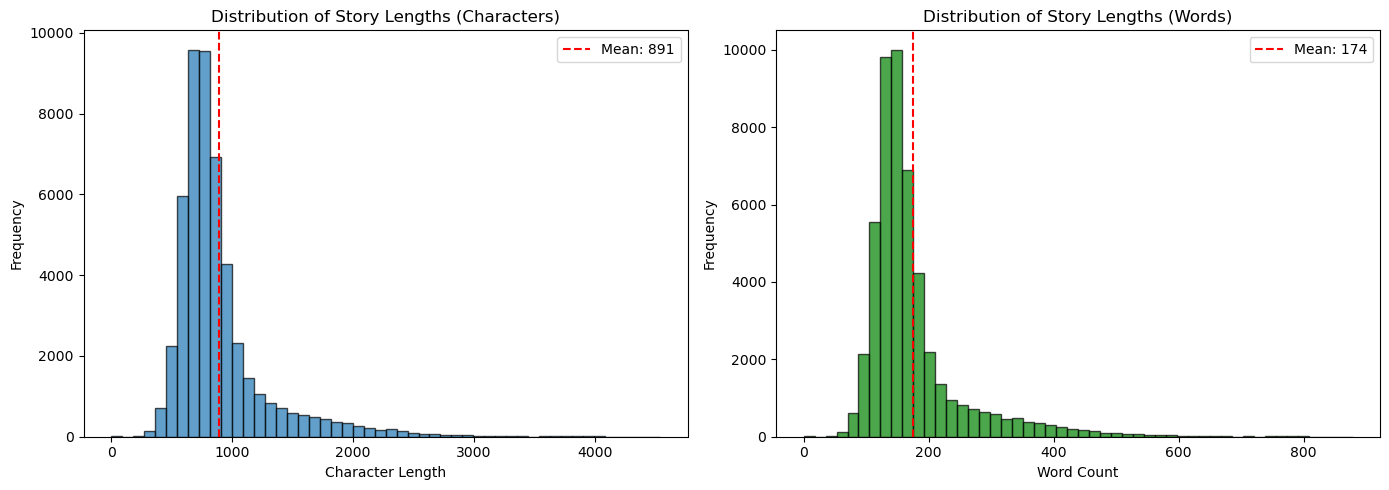

In [10]:
# Visualize length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length distribution
axes[0].hist(lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Story Lengths (Characters)')
axes[0].axvline(np.mean(lengths), color='r', linestyle='--', label=f'Mean: {np.mean(lengths):.0f}')
axes[0].legend()

# Word count distribution
axes[1].hist(word_counts, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Story Lengths (Words)')
axes[1].axvline(np.mean(word_counts), color='r', linestyle='--', label=f'Mean: {np.mean(word_counts):.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# Prepare training and validation data
# We'll extract all text and combine for tokenizer training

print("Preparing data for training...")

# Get all training texts
train_texts = [item['text'] for item in tqdm(dataset['train'], desc="Loading train")]
val_texts = [item['text'] for item in tqdm(dataset['validation'], desc="Loading validation")]

print(f"\nLoaded {len(train_texts):,} training texts")
print(f"Loaded {len(val_texts):,} validation texts")

# Calculate total characters
total_train_chars = sum(len(t) for t in train_texts)
total_val_chars = sum(len(t) for t in val_texts)
print(f"\nTotal training characters: {total_train_chars:,} ({total_train_chars/1e9:.2f} GB)")
print(f"Total validation characters: {total_val_chars:,}")

Preparing data for training...


Loading train:   0%|          | 0/2119719 [00:00<?, ?it/s]

Loading validation:   0%|          | 0/21990 [00:00<?, ?it/s]


Loaded 2,119,719 training texts
Loaded 21,990 validation texts

Total training characters: 1,899,973,203 (1.90 GB)
Total validation characters: 19,190,318


# Part 3: Tokenization

---
## What is Tokenization?

Tokenization is the process of converting raw text into a sequence of numbers (tokens) that a neural network can process. Since neural networks can only work with numerical data, we need a systematic way to represent text.

### Why Not Just Use Characters?

You might wonder: why not just assign each character a number? While this is possible (and some models do this), it has drawbacks:

1. **Long sequences**: Text becomes very long when represented character-by-character. "Hello" becomes 5 tokens instead of 1.
2. **No semantic meaning**: Characters don't carry meaning on their own. 'H' and 'e' don't tell the model much.
3. **Inefficient learning**: The model must learn to combine characters into meaningful units.

### Why Not Just Use Words?

Using whole words seems intuitive, but has problems too:

1. **Huge vocabulary**: English has 170,000+ words. Rare words get little training.
2. **Out-of-vocabulary (OOV)**: New or misspelled words can't be handled.
3. **Morphology**: "run", "runs", "running" are separate tokens with no shared representation.

## Byte Pair Encoding (BPE): The Best of Both Worlds

BPE is a subword tokenization algorithm that:
- Starts with individual characters (bytes)
- Iteratively merges the most frequent pairs
- Results in a vocabulary of common subwords

### How BPE Works (Step-by-Step)

Let's tokenize a tiny corpus: `"low lower lowest"`

**Step 1: Start with characters**
```
Vocabulary: ['l', 'o', 'w', 'e', 'r', 's', 't', ' ']
Tokens: ['l', 'o', 'w', ' ', 'l', 'o', 'w', 'e', 'r', ' ', 'l', 'o', 'w', 'e', 's', 't']
```

**Step 2: Count adjacent pairs**
```
('l', 'o'): 3, ('o', 'w'): 3, ('w', ' '): 1, ('w', 'e'): 2, ...
```

**Step 3: Merge most frequent pair** `('l', 'o')` -> `'lo'`
```
Vocabulary: ['l', 'o', 'w', 'e', 'r', 's', 't', ' ', 'lo']
Tokens: ['lo', 'w', ' ', 'lo', 'w', 'e', 'r', ' ', 'lo', 'w', 'e', 's', 't']
```

**Step 4: Repeat** - Merge `('lo', 'w')` -> `'low'`
```
Vocabulary: [..., 'low']
Tokens: ['low', ' ', 'low', 'e', 'r', ' ', 'low', 'e', 's', 't']
```

**Continue until** reaching desired vocabulary size or no more frequent pairs.

### Vocabulary Size Tradeoffs

| Vocab Size | Pros | Cons |
|------------|------|------|
| Small (~1K) | Less parameters in embedding layer, faster training | Longer sequences, less semantic meaning per token |
| Medium (~16K-32K) | Good balance for most tasks | - |
| Large (~50K+) | Shorter sequences, more semantic tokens | More parameters, rare tokens undertrained |

For TinyStories, we'll use **16,384 tokens** - a good balance for our ~34M default model (and still reasonable for ~60M+).

---

We'll implement two approaches:
1. **BPE from Scratch** - Educational implementation to understand the algorithm
2. **Production Tokenizer** - Using HuggingFace tokenizers for actual training


## 3A: BPE Tokenizer from Scratch (Educational)

In [17]:
class SimpleBPE:
    """
    A simple Byte Pair Encoding (BPE) tokenizer implementation from scratch.
    Based on the original BPE algorithm by Sennrich et al. and inspired by Karpathy's minbpe.
    """
    
    def __init__(self):
        self.merges = {}  # (pair) -> new_token_id
        self.vocab = {}   # token_id -> bytes
        self.inverse_vocab = {}  # bytes -> token_id
        
    def _get_stats(self, ids: List[int]) -> Dict[Tuple[int, int], int]:
        """Count frequency of adjacent pairs in the token sequence."""
        counts = {}
        for pair in zip(ids, ids[1:]):
            counts[pair] = counts.get(pair, 0) + 1
        return counts
    
    def _merge(self, ids: List[int], pair: Tuple[int, int], new_id: int) -> List[int]:
        """Replace all occurrences of pair with new_id in the sequence."""
        new_ids = []
        i = 0
        while i < len(ids):
            if i < len(ids) - 1 and ids[i] == pair[0] and ids[i+1] == pair[1]:
                new_ids.append(new_id)
                i += 2
            else:
                new_ids.append(ids[i])
                i += 1
        return new_ids
    
    def train(self, text: str, vocab_size: int, verbose: bool = True) -> None:
        """
        Train the BPE tokenizer on the given text.
        
        Args:
            text: Training text
            vocab_size: Desired vocabulary size (must be > 256 for byte-level BPE)
            verbose: Whether to print progress
        """
        assert vocab_size >= 256, "Vocab size must be at least 256 for byte-level BPE"
        
        num_merges = vocab_size - 256
        
        # Convert text to bytes, then to list of integers (0-255)
        text_bytes = text.encode('utf-8')
        ids = list(text_bytes)
        
        # Initialize vocabulary with single bytes
        self.vocab = {i: bytes([i]) for i in range(256)}
        self.inverse_vocab = {bytes([i]): i for i in range(256)}
        self.merges = {}
        
        if verbose:
            print(f"Training BPE with {num_merges} merges...")
            print(f"Initial sequence length: {len(ids):,}")
        
        # Perform merges
        for i in tqdm(range(num_merges), disable=not verbose, desc="BPE Training"):
            # Get pair statistics
            stats = self._get_stats(ids)
            if not stats:
                break
                
            # Find most frequent pair
            top_pair = max(stats, key=stats.get)
            
            # Create new token
            new_id = 256 + i
            
            # Merge the pair
            ids = self._merge(ids, top_pair, new_id)
            
            # Update vocabulary and merges
            self.merges[top_pair] = new_id
            new_bytes = self.vocab[top_pair[0]] + self.vocab[top_pair[1]]
            self.vocab[new_id] = new_bytes
            self.inverse_vocab[new_bytes] = new_id
            
            if verbose and (i + 1) % 100 == 0:
                print(f"  Merge {i+1}: {top_pair} -> {new_id} (freq: {stats[top_pair]})")
        
        if verbose:
            print(f"\nFinal sequence length: {len(ids):,}")
            print(f"Compression ratio: {len(text_bytes) / len(ids):.2f}x")
            print(f"Vocabulary size: {len(self.vocab)}")
    
    def encode(self, text: str) -> List[int]:
        """Encode text to a list of token IDs."""
        # Convert to bytes
        text_bytes = text.encode('utf-8')
        ids = list(text_bytes)
        
        # Apply merges in order
        while len(ids) >= 2:
            # Find all pairs and their merge priority
            stats = self._get_stats(ids)
            
            # Find the pair with lowest merge index (highest priority)
            pair = min(stats, key=lambda p: self.merges.get(p, float('inf')))
            
            # If no more merges possible, break
            if pair not in self.merges:
                break
            
            # Apply the merge
            new_id = self.merges[pair]
            ids = self._merge(ids, pair, new_id)
        
        return ids
    
    def decode(self, ids: List[int]) -> str:
        """Decode a list of token IDs back to text."""
        text_bytes = b''.join(self.vocab[id] for id in ids)
        return text_bytes.decode('utf-8', errors='replace')
    
    def get_vocab_size(self) -> int:
        """Return the vocabulary size."""
        return len(self.vocab)
    
    def save(self, path: str) -> None:
        """Save the tokenizer to a file."""
        with open(path, 'wb') as f:
            pickle.dump({'merges': self.merges, 'vocab': self.vocab}, f)
    
    def load(self, path: str) -> None:
        """Load the tokenizer from a file."""
        with open(path, 'rb') as f:
            data = pickle.load(f)
            self.merges = data['merges']
            self.vocab = data['vocab']
            self.inverse_vocab = {v: k for k, v in self.vocab.items()}

In [18]:
# Train a small BPE tokenizer on a subset of data for demonstration
print("Training BPE tokenizer from scratch (educational demo)...")
print("Using a small subset for quick demonstration\n")

# Use a small sample for demonstration
demo_text = " ".join(train_texts[:1000])  # First 1000 stories
print(f"Demo text length: {len(demo_text):,} characters")

# Create and train tokenizer
simple_bpe = SimpleBPE()
simple_bpe.train(demo_text, vocab_size=512, verbose=True)

Training BPE tokenizer from scratch (educational demo)...
Using a small subset for quick demonstration

Demo text length: 942,639 characters
Training BPE with 256 merges...
Initial sequence length: 944,425


BPE Training:   0%|          | 0/256 [00:00<?, ?it/s]

  Merge 100: (276, 32) -> 355 (freq: 1268)
  Merge 200: (281, 354) -> 455 (freq: 614)

Final sequence length: 406,405
Compression ratio: 2.32x
Vocabulary size: 512


In [19]:
# Test the tokenizer
test_text = "Once upon a time, there was a little girl named Lily."

print("Testing our BPE tokenizer:")
print(f"Original: {test_text}")

encoded = simple_bpe.encode(test_text)
print(f"Encoded: {encoded}")
print(f"Number of tokens: {len(encoded)}")

decoded = simple_bpe.decode(encoded)
print(f"Decoded: {decoded}")
print(f"Round-trip successful: {test_text == decoded}")

Testing our BPE tokenizer:
Original: Once upon a time, there was a little girl named Lily.
Encoded: [352, 478, 394, 476, 405, 499, 110, 342, 267, 347, 121, 46]
Number of tokens: 12
Decoded: Once upon a time, there was a little girl named Lily.
Round-trip successful: True


In [20]:
# Visualize some vocabulary items
print("\nSample vocabulary items (showing merged tokens):")
print("-" * 40)

# Show some interesting merged tokens
for token_id in range(256, min(300, len(simple_bpe.vocab))):
    token_bytes = simple_bpe.vocab[token_id]
    try:
        token_str = token_bytes.decode('utf-8')
        print(f"Token {token_id}: '{token_str}' ({len(token_bytes)} bytes)")
    except:
        print(f"Token {token_id}: {token_bytes} ({len(token_bytes)} bytes)")


Sample vocabulary items (showing merged tokens):
----------------------------------------
Token 256: 'e ' (2 bytes)
Token 257: 'd ' (2 bytes)
Token 258: 'th' (2 bytes)
Token 259: '. ' (2 bytes)
Token 260: ' a' (2 bytes)
Token 261: 't ' (2 bytes)
Token 262: 's ' (2 bytes)
Token 263: 'y ' (2 bytes)
Token 264: 'er' (2 bytes)
Token 265: 'nd ' (3 bytes)
Token 266: 'o ' (2 bytes)
Token 267: 'ed ' (3 bytes)
Token 268: 'the ' (4 bytes)
Token 269: 'in' (2 bytes)
Token 270: 'wa' (2 bytes)
Token 271: 'he ' (3 bytes)
Token 272: ', ' (2 bytes)
Token 273: 'ou' (2 bytes)
Token 274: ' and ' (5 bytes)
Token 275: 'to ' (3 bytes)
Token 276: 'en' (2 bytes)
Token 277: 'ar' (2 bytes)
Token 278: '

' (2 bytes)
Token 279: 'on' (2 bytes)
Token 280: 'om' (2 bytes)
Token 281: 'ha' (2 bytes)
Token 282: ' s' (2 bytes)
Token 283: 'ing' (3 bytes)
Token 284: 'he' (2 bytes)
Token 285: 'il' (2 bytes)
Token 286: 'or' (2 bytes)
Token 287: ' the ' (5 bytes)
Token 288: '. T' (3 bytes)
Token 289: 'an' (2 bytes)
Token 290: 

## 3B: Production Tokenizer (HuggingFace)

In [21]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders, processors

def train_production_tokenizer(texts: List[str], vocab_size: int = 16384, save_path: str = None):
    """
    Train a production-quality BPE tokenizer using HuggingFace tokenizers library.
    
    Args:
        texts: List of training texts
        vocab_size: Target vocabulary size
        save_path: Path to save the tokenizer
    
    Returns:
        Trained tokenizer
    """
    print(f"Training production BPE tokenizer with vocab_size={vocab_size}...")
    
    # Initialize a BPE tokenizer
    tokenizer = Tokenizer(models.BPE())
    
    # Pre-tokenizer: split on whitespace and punctuation
    tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    
    # Decoder
    tokenizer.decoder = decoders.ByteLevel()
    
    # Post-processor for special tokens
    tokenizer.post_processor = processors.ByteLevel(trim_offsets=False)
    
    # Trainer
    trainer = trainers.BpeTrainer(
        vocab_size=vocab_size,
        special_tokens=["<|endoftext|>", "<|padding|>", "<|unknown|>"],
        show_progress=True,
        min_frequency=2,
    )
    
    # Train from iterator
    def batch_iterator(batch_size=1000):
        for i in range(0, len(texts), batch_size):
            yield texts[i:i + batch_size]
    
    tokenizer.train_from_iterator(batch_iterator(), trainer=trainer, length=len(texts))
    
    # Save if path provided
    if save_path:
        tokenizer.save(save_path)
        print(f"Tokenizer saved to {save_path}")
    
    print(f"Vocabulary size: {tokenizer.get_vocab_size()}")
    return tokenizer

In [22]:
# Train production tokenizer on TinyStories
# Using a subset for faster training - use full dataset for best results

VOCAB_SIZE = 16384  # 16K vocabulary - good balance for small models

# Use subset for faster training (use train_texts for full training)
training_subset = train_texts[:100000]  # 100K stories for tokenizer training

tokenizer_path = str(TOKENIZER_DIR / "tinystories_bpe.json")

# Check if tokenizer already exists
if os.path.exists(tokenizer_path):
    print(f"Loading existing tokenizer from {tokenizer_path}")
    tokenizer = Tokenizer.from_file(tokenizer_path)
else:
    tokenizer = train_production_tokenizer(
        training_subset, 
        vocab_size=VOCAB_SIZE,
        save_path=tokenizer_path
    )

Loading existing tokenizer from /Users/every1/Desktop/local_llm_testing/local_llm_training/models/tokenizer/tinystories_bpe.json


In [23]:
# Test production tokenizer
test_texts = [
    "Once upon a time, there was a little girl named Lily.",
    "The quick brown fox jumps over the lazy dog.",
    "She loved to play with her toys and read books.",
]

print("Testing production tokenizer:")
print("=" * 60)

for text in test_texts:
    encoded = tokenizer.encode(text)
    decoded = tokenizer.decode(encoded.ids)
    
    print(f"\nOriginal: {text}")
    print(f"Tokens: {encoded.tokens}")
    print(f"IDs: {encoded.ids}")
    print(f"Decoded: {decoded}")
    print(f"Token count: {len(encoded.ids)}")

Testing production tokenizer:

Original: Once upon a time, there was a little girl named Lily.
Tokens: ['Once', 'Ġupon', 'Ġa', 'Ġtime', ',', 'Ġthere', 'Ġwas', 'Ġa', 'Ġlittle', 'Ġgirl', 'Ġnamed', 'ĠLily', '.']
IDs: [284, 300, 118, 252, 13, 256, 139, 118, 255, 301, 353, 223, 15]
Decoded: Once upon a time, there was a little girl named Lily.
Token count: 13

Original: The quick brown fox jumps over the lazy dog.
Tokens: ['The', 'Ġquick', 'Ġbrown', 'Ġfox', 'Ġjumps', 'Ġover', 'Ġthe', 'Ġlazy', 'Ġdog', '.']
IDs: [231, 912, 1731, 1507, 3648, 605, 122, 2623, 502, 15]
Decoded: The quick brown fox jumps over the lazy dog.
Token count: 10

Original: She loved to play with her toys and read books.
Tokens: ['She', 'Ġloved', 'Ġto', 'Ġplay', 'Ġwith', 'Ġher', 'Ġtoys', 'Ġand', 'Ġread', 'Ġbooks', '.']
IDs: [947, 358, 125, 220, 202, 168, 543, 124, 1234, 1336, 15]
Decoded: She loved to play with her toys and read books.
Token count: 11


### Tokenizer Wrapper Class

The `TinyStoriesTokenizer` class wraps the trained HuggingFace tokenizer with convenience methods for our training pipeline:

- `encode(text)`: Convert text to token IDs, optionally adding EOS token
- `decode(tokens)`: Convert token IDs back to text
- `get_vocab_size()`: Return vocabulary size for model configuration

This wrapper standardizes the interface regardless of the underlying tokenizer implementation.

In [25]:
# Create a wrapper class for our tokenizer
class TinyStoriesTokenizer:
    """
    Wrapper class for the trained BPE tokenizer with convenience methods.
    """
    
    def __init__(self, tokenizer_path: str):
        self.tokenizer = Tokenizer.from_file(tokenizer_path)
        self.vocab_size = self.tokenizer.get_vocab_size()
        
        # Special token IDs
        self.eos_token = "<|endoftext|>"
        self.pad_token = "<|padding|>"
        self.unk_token = "<|unknown|>"
        
        self.eos_token_id = self.tokenizer.token_to_id(self.eos_token)
        self.pad_token_id = self.tokenizer.token_to_id(self.pad_token)
        self.unk_token_id = self.tokenizer.token_to_id(self.unk_token)
    
    def encode(self, text: str, add_eos: bool = True) -> List[int]:
        """Encode text to token IDs."""
        ids = self.tokenizer.encode(text).ids
        if add_eos:
            ids = ids + [self.eos_token_id]
        return ids
    
    def decode(self, ids: List[int]) -> str:
        """Decode token IDs to text."""
        return self.tokenizer.decode(ids)
    
    def batch_encode(self, texts: List[str], add_eos: bool = True) -> List[List[int]]:
        """Encode multiple texts."""
        return [self.encode(text, add_eos) for text in texts]
    
    def __len__(self):
        return self.vocab_size


# Create tokenizer instance
tok = TinyStoriesTokenizer(tokenizer_path)
print(f"Tokenizer ready!")
print(f"Vocabulary size: {tok.vocab_size}")
print(f"EOS token ID: {tok.eos_token_id}")
print(f"PAD token ID: {tok.pad_token_id}")

Tokenizer ready!
Vocabulary size: 16384
EOS token ID: 0
PAD token ID: 1


# Part 4: Model Architecture from Scratch

---
## What is a Transformer?

The Transformer architecture (introduced in "Attention Is All You Need", 2017) revolutionized NLP by replacing recurrent networks with a purely attention-based mechanism. This allows for:

- **Parallelization**: Unlike RNNs, all positions can be processed simultaneously
- **Long-range dependencies**: Attention can directly connect distant tokens
- **Scalability**: Transformers scale efficiently with data and compute

## Decoder-Only Architecture for Language Models

There are three main transformer variants:

1. **Encoder-only** (BERT): Bidirectional, good for understanding tasks
2. **Encoder-Decoder** (T5): Input-output mapping, good for translation
3. **Decoder-only** (GPT): Left-to-right generation, good for text generation

We use **decoder-only** because language modeling is fundamentally about predicting the next token given previous context.

## Component Deep Dive

### 1. Token Embeddings

Converts token IDs to dense vectors:
```
token_id: 42 -> embedding: [0.12, -0.34, 0.56, ...]  (n_embd dimensions)
```

The embedding layer is a learnable lookup table of shape `(vocab_size, n_embd)`.

### 2. Positional Embeddings

Transformers have no inherent sense of position (unlike RNNs). Positional embeddings add position information:
```
position: 0 -> pos_embedding: [0.01, 0.02, -0.03, ...]
position: 1 -> pos_embedding: [0.04, -0.01, 0.02, ...]
```

We use **learnable positional embeddings** - a lookup table of shape `(block_size, n_embd)`.

### 3. Self-Attention Mechanism

Self-attention allows each token to "look at" other tokens and gather relevant information.

**Query, Key, Value (Q, K, V)**:
- **Query (Q)**: "What am I looking for?"
- **Key (K)**: "What do I contain?"
- **Value (V)**: "What information do I provide?"

**Attention computation**:
```
Attention(Q, K, V) = softmax(Q @ K^T / sqrt(d_k)) @ V
```

**Scaling by sqrt(d_k)**: Prevents dot products from growing too large, which would push softmax into regions with tiny gradients.

### 4. Causal Masking

In language modeling, we can only attend to **past and current** tokens (not future). Causal masking enforces this:
```
Mask:     Position 0  Position 1  Position 2
Token 0:     1           0           0        <- Can only see itself
Token 1:     1           1           0        <- Can see 0 and itself
Token 2:     1           1           1        <- Can see all previous
```

We apply the mask before softmax by setting future positions to -infinity.

### 5. Multi-Head Attention

Instead of one attention, we use multiple "heads" that attend to different aspects:
- Head 1 might focus on syntax
- Head 2 might focus on semantics
- Head 3 might focus on recent context

Each head has its own Q, K, V projections. Outputs are concatenated and projected.

### 6. Feed-Forward Network (FFN)

After attention, each position goes through an identical FFN:
```
FFN(x) = GELU(x @ W1 + b1) @ W2 + b2
```

The FFN has a hidden dimension of `4 * n_embd` (expansion then compression). This is where much of the model's "knowledge" is stored.

### 7. Layer Normalization

Normalizes activations for stable training:
```
LayerNorm(x) = (x - mean(x)) / std(x) * gamma + beta
```

We use **Pre-LayerNorm** (normalize before attention/FFN) which is more stable than Post-LayerNorm.

### 8. Residual Connections

Each sub-layer has a residual (skip) connection:
```
output = x + Sublayer(LayerNorm(x))
```

This helps gradients flow and enables training of deep networks.

## Configuration Parameters Explained

| Parameter | Meaning | Our Value | Intuition |
|-----------|---------|-----------|-----------|
| `vocab_size` | Number of unique tokens | 16,384 | Determined by tokenizer |
| `n_embd` | Hidden dimension | 512 | Larger = more capacity |
| `n_head` | Attention heads | 8 | Should divide n_embd evenly |
| `n_layer` | Transformer blocks | 8 | Deeper = more reasoning steps |
| `block_size` | Max sequence length | 512 | Context window size |
| `dropout` | Regularization rate | 0.1 | Prevents overfitting |
| `bias` | Use bias in linear layers | False | Slightly faster, modern default |

## Parameter Count (and why you may see ~25M vs ~34M)

For the default config in this notebook (`vocab_size=16,384`, `block_size=512`, `n_embd=512`, `n_layer=8`, `bias=False`), the **total parameter count is ~33.8M**.

If you’re getting **~25M**, you’re probably counting only the **transformer blocks** and not the embedding tables. Below is the full breakdown (matching the code implementation).

### 1) Embeddings

- **Token embedding table**: `vocab_size * n_embd`
  - `16,384 * 512 = 8,388,608` (~8.39M)
- **Positional embedding table**: `block_size * n_embd`
  - `512 * 512 = 262,144` (~0.26M)

Embeddings total: `8,650,752` (~8.65M).

### 2) Parameters per Transformer Block

A standard GPT block (pre-norm) contains: **self-attention**, an **MLP/FFN**, and **two LayerNorms**.

Important notes:
- `n_head` changes *how we reshape tensors* during attention, but **does not change parameter count** when `n_embd` is fixed.
- In this notebook, `bias=False` applies to **Linear layers** (attention/MLP projections). **LayerNorm still has weight+bias** by default in PyTorch (`nn.LayerNorm(elementwise_affine=True)`).

#### 2.1 Self-attention (weights only when `bias=False`)
We implement a fused QKV projection plus an output projection:

- `W_qkv`: `n_embd x (3*n_embd)` → `512 x 1536 = 786,432`
- `W_out`: `n_embd x n_embd` → `512 x 512 = 262,144`
- Attention total: `1,048,576` (= `4 * n_embd^2`)

#### 2.2 MLP/FFN (4x expansion, weights only when `bias=False`)

- `W_up`: `n_embd x (4*n_embd)` → `512 x 2048 = 1,048,576`
- `W_down`: `(4*n_embd) x n_embd` → `2048 x 512 = 1,048,576`
- MLP total: `2,097,152` (= `8 * n_embd^2`)

#### 2.3 LayerNorms

Each LayerNorm has a learnable **weight and bias** of length `n_embd`:

- 1 LayerNorm: `2 * n_embd = 1,024` params
- 2 LayerNorms per block: `2,048` params

#### 2.4 Per-block + all-blocks total

- Per block: `1,048,576 + 2,097,152 + 2,048 = 3,147,776` (~3.15M)
- 8 blocks: `25,182,208` (~25.2M)

### 3) Final LayerNorm + LM head

- **Final LayerNorm**: `2 * n_embd = 1,024` params
- **LM head**: **0 extra params** because we use **weight tying** (`lm_head.weight` shares the same weights as the token embedding table).

### 4) Grand total (default config)

- Embeddings: `8,650,752`
- Blocks: `25,182,208`
- Final LN: `1,024`
- **Total: `33,833,984` (~33.8M ≈ ~34M)**

### Getting to ~60M parameters

This notebook’s **default** model is ~34M. If you want ~60M, increase `n_embd` and/or `n_layer`. A rough rule for this architecture is: per block ≈ `12 * n_embd^2` params (plus small `O(n_embd)` terms). For example, keeping `vocab_size=16,384` and `block_size=512`:

- `n_embd=640`, `n_layer=10` → ~60M params
- `n_embd=768`, `n_layer=6` → mid-50M params

---

We'll implement both PyTorch and MLX versions side-by-side.


In [21]:
# Model Configuration
@dataclass
class GPTConfig:
    """Configuration for GPT model."""
    vocab_size: int = 16384       # Vocabulary size (matches tokenizer)
    block_size: int = 512         # Maximum context length
    n_embd: int = 512             # Embedding dimension
    n_head: int = 8               # Number of attention heads
    n_layer: int = 8              # Number of transformer blocks
    dropout: float = 0.1          # Dropout rate
    bias: bool = False            # Use bias in linear layers
    
    def __post_init__(self):
        assert self.n_embd % self.n_head == 0, "n_embd must be divisible by n_head"
    
    @property
    def head_dim(self):
        return self.n_embd // self.n_head
    def estimate_params(self, tie_word_embeddings: bool = True) -> int:
        """Estimate total parameters in the model.

        Notes:
        - `bias` controls Linear-layer biases only (attention/MLP projections).
        - LayerNorm has weight+bias by default in PyTorch (so it always contributes parameters).
        - If `tie_word_embeddings=True` (default in our GPT implementation), the LM head adds 0 extra params.
        """
        # Embeddings
        token_emb = self.vocab_size * self.n_embd
        pos_emb = self.block_size * self.n_embd
        emb_params = token_emb + pos_emb

        # Self-attention projections: W_qkv (n_embd x 3n_embd) + W_out (n_embd x n_embd)
        attn_params = 4 * self.n_embd * self.n_embd
        if self.bias:
            attn_params += 4 * self.n_embd  # qkv bias (3*n_embd) + out bias (n_embd)

        # MLP/FFN projections (4x expansion): W_up + W_down
        ffn_params = 8 * self.n_embd * self.n_embd
        if self.bias:
            ffn_params += 5 * self.n_embd  # up bias (4*n_embd) + down bias (n_embd)

        # Two LayerNorms per block; each has (weight+bias) => 2*n_embd
        ln_params = 4 * self.n_embd

        block_params = attn_params + ffn_params + ln_params

        # Final LayerNorm (weight+bias)
        final_ln_params = 2 * self.n_embd

        # LM head (bias=False in our implementation)
        lm_head_params = 0 if tie_word_embeddings else (self.vocab_size * self.n_embd)

        total = emb_params + (self.n_layer * block_params) + final_ln_params + lm_head_params
        return total


# Create default configuration (~34M parameters with tied embeddings)
config = GPTConfig()
print("Model Configuration:")
print(f"  Vocabulary size: {config.vocab_size:,}")
print(f"  Context length: {config.block_size}")
print(f"  Embedding dim: {config.n_embd}")
print(f"  Attention heads: {config.n_head}")
print(f"  Head dimension: {config.head_dim}")
print(f"  Layers: {config.n_layer}")
print(f"  Dropout: {config.dropout}")
print(f"\nEstimated parameters: {config.estimate_params():,} (~{config.estimate_params()/1e6:.1f}M)")

Model Configuration:
  Vocabulary size: 16,384
  Context length: 512
  Embedding dim: 512
  Attention heads: 8
  Head dimension: 64
  Layers: 8
  Dropout: 0.1

Estimated parameters: 33,833,984 (~33.8M)


## 4A: PyTorch Implementation

In [22]:
class CausalSelfAttention(nn.Module):
    """
    Multi-head causal self-attention.
    Uses Flash Attention when available via scaled_dot_product_attention.
    """
    
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.head_dim = config.head_dim
        self.dropout = config.dropout
        
        # Key, Query, Value projections combined for efficiency
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        
        # Output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        
        # Regularization
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        
        # Causal mask (registered as buffer so it moves to device with model)
        self.register_buffer(
            "mask",
            torch.tril(torch.ones(config.block_size, config.block_size))
            .view(1, 1, config.block_size, config.block_size)
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape  # Batch, Sequence length, Embedding dim
        
        # Calculate Q, K, V
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        
        # Reshape for multi-head attention: (B, T, n_head, head_dim) -> (B, n_head, T, head_dim)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        
        # Use PyTorch's optimized attention (Flash Attention when available)
        if hasattr(F, 'scaled_dot_product_attention'):
            # Use optimized attention
            y = F.scaled_dot_product_attention(
                q, k, v,
                attn_mask=None,
                dropout_p=self.dropout if self.training else 0.0,
                is_causal=True
            )
        else:
            # Manual attention computation
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(self.head_dim))
            att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v
        
        # Reassemble heads
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        
        # Output projection
        y = self.resid_dropout(self.c_proj(y))
        return y


class FeedForward(nn.Module):
    """
    Feed-forward network with GELU activation.
    Expansion factor of 4x is standard for transformers.
    """
    
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x


class TransformerBlock(nn.Module):
    """
    Transformer block with pre-norm architecture.
    Pre-norm is more stable for training than post-norm.
    """
    
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.ffn = FeedForward(config)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Pre-norm with residual connections
        x = x + self.attn(self.ln_1(x))
        x = x + self.ffn(self.ln_2(x))
        return x

### Full GPT Model

The `GPT` class combines all components into the complete language model:

**Forward Pass Flow**:
1. Token IDs → Token embeddings + Position embeddings
2. Combined embeddings → Stack of Transformer blocks
3. Final LayerNorm → Language model head (logits)

**Key Methods**:
- `forward(idx, targets)`: Returns logits and optionally computes loss
- `generate()`: Autoregressive text generation with sampling
- `crop_block_size()`: Adjusts model for shorter sequences

The model uses **weight tying** between token embeddings and the output layer.

In [ ]:
class GPT(nn.Module):
    """
    Full GPT model combining all components.
    """
    
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config
        
        # Token and position embeddings
        self.wte = nn.Embedding(config.vocab_size, config.n_embd)  # Token embeddings
        self.wpe = nn.Embedding(config.block_size, config.n_embd)  # Position embeddings
        self.drop = nn.Dropout(config.dropout)
        
        # Transformer blocks
        self.blocks = nn.ModuleList([TransformerBlock(config) for _ in range(config.n_layer)])
        
        # Final layer norm
        self.ln_f = nn.LayerNorm(config.n_embd)
        
        # Language modeling head (weight sharing with token embeddings)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        
        # Weight tying: share weights between embedding and lm_head
        self.wte.weight = self.lm_head.weight
        
        # Initialize weights
        self.apply(self._init_weights)
        
        # Special scaled init for residual projections (per GPT-2 paper)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))
        
        # Report number of parameters
        n_params = sum(p.numel() for p in self.parameters())
        print(f"GPT model initialized with {n_params:,} parameters ({n_params/1e6:.2f}M)")
    
    def _init_weights(self, module):
        """Initialize weights following GPT-2 conventions."""
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
    
    def forward(
        self, 
        idx: torch.Tensor, 
        targets: Optional[torch.Tensor] = None
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """
        Forward pass.
        
        Args:
            idx: Input token indices (B, T)
            targets: Target token indices for loss computation (B, T)
        
        Returns:
            logits: Output logits (B, T, vocab_size)
            loss: Cross-entropy loss if targets provided, else None
        """
        B, T = idx.shape
        
        assert T <= self.config.block_size, f"Sequence length {T} exceeds block size {self.config.block_size}"
        
        # Get position indices
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        
        # Token + position embeddings
        tok_emb = self.wte(idx)  # (B, T, n_embd)
        pos_emb = self.wpe(pos)  # (T, n_embd)
        x = self.drop(tok_emb + pos_emb)
        
        # Transformer blocks
        for block in self.blocks:
            x = block(x)
        
        # Final layer norm and LM head
        x = self.ln_f(x)
        logits = self.lm_head(x)  # (B, T, vocab_size)
        
        # Calculate loss if targets provided
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)), 
                targets.view(-1),
                ignore_index=-1  # Ignore padding tokens
            )
        
        return logits, loss
    
    @torch.no_grad()
    def generate(
        self,
        idx: torch.Tensor,
        max_new_tokens: int,
        temperature: float = 1.0,
        top_k: Optional[int] = None,
        top_p: Optional[float] = None,
        eos_token_id: Optional[int] = None,
    ) -> torch.Tensor:
        """
        Generate new tokens autoregressively.
        
        Args:
            idx: Starting token indices (B, T)
            max_new_tokens: Number of new tokens to generate
            temperature: Sampling temperature (higher = more random)
            top_k: Keep only top k tokens
            top_p: Nucleus sampling threshold
            eos_token_id: Stop generation when this token is produced
        
        Returns:
            Generated token indices (B, T + max_new_tokens)
        """
        self.eval()
        
        for _ in range(max_new_tokens):
            # Crop to block size if needed
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            
            # Forward pass
            logits, _ = self(idx_cond)
            
            # Get logits for last position
            logits = logits[:, -1, :] / temperature
            
            # Optional top-k filtering
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')
            
            # Optional top-p (nucleus) filtering
            if top_p is not None:
                sorted_logits, sorted_indices = torch.sort(logits, descending=True)
                cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
                
                # Remove tokens with cumulative probability above the threshold
                sorted_indices_to_remove = cumulative_probs > top_p
                sorted_indices_to_remove[:, 1:] = sorted_indices_to_remove[:, :-1].clone()
                sorted_indices_to_remove[:, 0] = 0
                
                indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
                logits[indices_to_remove] = float('-inf')
            
            # Sample from distribution
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            
            # Append to sequence
            idx = torch.cat([idx, idx_next], dim=1)
            
            # Stop if EOS token generated
            if eos_token_id is not None and (idx_next == eos_token_id).all():
                break
        
        return idx

In [24]:
# Test PyTorch model instantiation
print("Creating PyTorch GPT model...")

# Update config to match tokenizer vocab size
config.vocab_size = tok.vocab_size

model = GPT(config)
model = model.to(DEVICE)

# Test forward pass
print("\nTesting forward pass...")
test_input = torch.randint(0, config.vocab_size, (2, 64), device=DEVICE)
test_target = torch.randint(0, config.vocab_size, (2, 64), device=DEVICE)

with torch.no_grad():
    logits, loss = model(test_input, test_target)
    
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {logits.shape}")
print(f"Loss: {loss.item():.4f}")
print(f"Expected initial loss (random): ~{math.log(config.vocab_size):.4f}")

# Memory usage
if DEVICE.type == 'mps':
    print(f"\nMPS memory allocated: ~{torch.mps.driver_allocated_memory() / 1e9:.2f} GB")

Creating PyTorch GPT model...
GPT model initialized with 33,833,984 parameters (33.83M)

Testing forward pass...
Input shape: torch.Size([2, 64])
Output shape: torch.Size([2, 64, 16384])
Loss: 9.8420
Expected initial loss (random): ~9.7041

MPS memory allocated: ~1.16 GB


## 4B: MLX Implementation

MLX is Apple's machine learning framework optimized for Apple Silicon. It has a NumPy-like API and supports lazy evaluation.

In [25]:
if MLX_AVAILABLE:
    import mlx.core as mx
    import mlx.nn as mlx_nn
    
    class MLXCausalSelfAttention(mlx_nn.Module):
        """Multi-head causal self-attention in MLX."""
        
        def __init__(self, config: GPTConfig):
            super().__init__()
            self.n_head = config.n_head
            self.n_embd = config.n_embd
            self.head_dim = config.head_dim
            
            # Combined QKV projection
            self.c_attn = mlx_nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
            self.c_proj = mlx_nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        
        def __call__(self, x: mx.array, mask: mx.array = None) -> mx.array:
            B, T, C = x.shape
            
            # QKV projection
            qkv = self.c_attn(x)
            q, k, v = mx.split(qkv, 3, axis=-1)
            
            # Reshape for multi-head attention
            q = q.reshape(B, T, self.n_head, self.head_dim).transpose(0, 2, 1, 3)
            k = k.reshape(B, T, self.n_head, self.head_dim).transpose(0, 2, 1, 3)
            v = v.reshape(B, T, self.n_head, self.head_dim).transpose(0, 2, 1, 3)
            
            # Scaled dot-product attention
            scale = 1.0 / math.sqrt(self.head_dim)
            att = (q @ k.transpose(0, 1, 3, 2)) * scale
            
            # Causal mask
            if mask is None:
                mask = mx.triu(mx.full((T, T), -1e9), k=1)
            att = att + mask
            
            att = mx.softmax(att, axis=-1)
            y = att @ v
            
            # Reassemble heads
            y = y.transpose(0, 2, 1, 3).reshape(B, T, C)
            return self.c_proj(y)
    
    
    class MLXFeedForward(mlx_nn.Module):
        """Feed-forward network in MLX."""
        
        def __init__(self, config: GPTConfig):
            super().__init__()
            self.c_fc = mlx_nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
            self.c_proj = mlx_nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        
        def __call__(self, x: mx.array) -> mx.array:
            x = self.c_fc(x)
            x = mlx_nn.gelu(x)
            x = self.c_proj(x)
            return x
    
    
    class MLXTransformerBlock(mlx_nn.Module):
        """Transformer block in MLX."""
        
        def __init__(self, config: GPTConfig):
            super().__init__()
            self.ln_1 = mlx_nn.LayerNorm(config.n_embd)
            self.attn = MLXCausalSelfAttention(config)
            self.ln_2 = mlx_nn.LayerNorm(config.n_embd)
            self.ffn = MLXFeedForward(config)
        
        def __call__(self, x: mx.array, mask: mx.array = None) -> mx.array:
            x = x + self.attn(self.ln_1(x), mask)
            x = x + self.ffn(self.ln_2(x))
            return x
    
    
    class MLXGPT(mlx_nn.Module):
        """Full GPT model in MLX."""
        
        def __init__(self, config: GPTConfig):
            super().__init__()
            self.config = config
            
            self.wte = mlx_nn.Embedding(config.vocab_size, config.n_embd)
            self.wpe = mlx_nn.Embedding(config.block_size, config.n_embd)
            
            self.blocks = [MLXTransformerBlock(config) for _ in range(config.n_layer)]
            self.ln_f = mlx_nn.LayerNorm(config.n_embd)
            
            # LM head (no weight tying for simplicity)
            self.lm_head = mlx_nn.Linear(config.n_embd, config.vocab_size, bias=False)
        
        def __call__(self, idx: mx.array) -> mx.array:
            B, T = idx.shape
            
            # Embeddings
            pos = mx.arange(T)
            tok_emb = self.wte(idx)
            pos_emb = self.wpe(pos)
            x = tok_emb + pos_emb
            
            # Causal mask
            mask = mx.triu(mx.full((T, T), -1e9), k=1)
            
            # Transformer blocks
            for block in self.blocks:
                x = block(x, mask)
            
            # Output
            x = self.ln_f(x)
            logits = self.lm_head(x)
            return logits
        
        def generate(self, idx: mx.array, max_new_tokens: int, temperature: float = 1.0) -> mx.array:
            """Generate tokens autoregressively."""
            for _ in range(max_new_tokens):
                idx_cond = idx if idx.shape[1] <= self.config.block_size else idx[:, -self.config.block_size:]
                logits = self(idx_cond)
                logits = logits[:, -1, :] / temperature
                probs = mx.softmax(logits, axis=-1)
                idx_next = mx.random.categorical(mx.log(probs))
                idx_next = idx_next.reshape(-1, 1)
                idx = mx.concatenate([idx, idx_next], axis=1)
            return idx
    
    print("MLX model classes defined successfully!")
else:
    print("MLX not available - skipping MLX model definition")

MLX model classes defined successfully!


# Part 5: Training Pipeline

---
## What is Language Model Training?

Language model training is **next-token prediction**. Given a sequence of tokens, predict what comes next:

```
Input:   "The cat sat on the"
Target:  "cat sat on the mat"
```

The model learns to maximize the probability of the correct next token at each position.

## Cross-Entropy Loss

Cross-entropy loss measures how well the model's predicted probability distribution matches the true distribution (one-hot encoded target):

```
Loss = -sum(y_true * log(y_pred))
```

For next-token prediction with vocabulary V and correct token c:
```
Loss = -log(P(token_c))
```

Lower loss = higher probability assigned to correct tokens = better model.

**Perplexity** is exp(loss) - intuitively, how many tokens the model is "confused" between. Lower is better. A perplexity of 10 means the model is as uncertain as randomly choosing between 10 tokens.

## Why AdamW Optimizer?

**Adam** combines:
- **Momentum**: Smooths gradients over time, helping escape local minima
- **Adaptive learning rates**: Each parameter gets its own learning rate based on gradient history

**AdamW** adds **decoupled weight decay** - penalizes large weights separately from the gradient update. This is crucial for:
- Preventing overfitting
- Improving generalization
- Works better than L2 regularization in Adam

Our hyperparameters:
```python
betas=(0.9, 0.95)   # Momentum decay rates
weight_decay=0.1    # Regularization strength
```

## Learning Rate Scheduling

Training with a fixed learning rate is suboptimal. Modern LLM training uses:

### 1. Linear Warmup (first ~2% of steps)
Start with tiny LR and linearly increase to max. This:
- Prevents early training instability
- Allows model to find a good region before taking large steps

### 2. Cosine Decay (remaining steps)
Smoothly decay LR following a cosine curve. This:
- Allows fast initial learning
- Fine-grained optimization near the end
- Smoother than step decay

```
warmup:  LR = max_lr * (step / warmup_steps)
decay:   LR = min_lr + 0.5 * (max_lr - min_lr) * (1 + cos(pi * progress))
```

## Gradient Accumulation

**Problem**: Large batch sizes improve training but require more GPU memory.

**Solution**: Accumulate gradients over multiple "micro-batches" before updating:
```python
for micro_batch in range(gradient_accumulation_steps):
    loss = model(micro_batch) / gradient_accumulation_steps
    loss.backward()  # Gradients accumulate
optimizer.step()     # Update once after accumulation
```

**Effective batch size** = batch_size × gradient_accumulation_steps

Our config: 32 × 4 = **128 effective batch size**

## Gradient Clipping

Large gradients can cause unstable updates. We clip gradients to max norm:
```python
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```

This rescales gradients if their total norm exceeds the threshold, preventing:
- NaN losses from exploding gradients
- Erratic training dynamics

## Training Loop Summary

```
for step in range(max_steps):
    1. Update learning rate (warmup/decay schedule)
    2. Zero gradients
    3. Gradient accumulation loop:
       a. Get batch (x, y)
       b. Forward pass: logits = model(x)
       c. Compute loss (cross-entropy between logits and y)
       d. Backward pass: loss.backward()
    4. Clip gradients
    5. Optimizer step
    6. Log metrics (every log_interval steps)
    7. Evaluate on validation set (every eval_interval steps)
    8. Save checkpoint (every save_interval steps)
```

## Checkpointing

We save:
- **Best model** (lowest validation loss) - for final use
- **Periodic checkpoints** - for resuming interrupted training
- **Final model** - last state

Each checkpoint contains:
```python
{
    'step': current_step,
    'model_state_dict': model weights,
    'optimizer_state_dict': optimizer state (momentum, etc.),
    'val_loss': validation loss,
    'config': model configuration
}
```

---

This section implements:
1. Dataset class for tokenized sequences
2. Training loop with gradient accumulation
3. Learning rate scheduling (warmup + cosine decay)
4. Checkpointing and logging


### Data Loading Utilities

**TextDataset**: A PyTorch Dataset that:
- Tokenizes text on-the-fly or uses pre-tokenized data
- Creates input-target pairs for next-token prediction (x[:-1], y[1:])
- Handles padding for variable-length sequences

**create_dataloaders()**: Creates train/val DataLoaders with:
- Shuffling for training data
- Configurable batch size
- Automatic batching and collation

In [26]:
class TextDataset(Dataset):
    """
    Dataset for language modeling.
    Tokenizes texts and creates fixed-length sequences for training.
    """
    
    def __init__(
        self, 
        texts: List[str], 
        tokenizer: TinyStoriesTokenizer, 
        block_size: int,
        stride: Optional[int] = None
    ):
        """
        Args:
            texts: List of text strings
            tokenizer: Tokenizer instance
            block_size: Sequence length for training
            stride: Step size for creating sequences (default: block_size)
        """
        self.block_size = block_size
        self.stride = stride or block_size
        
        # Tokenize all texts and concatenate
        print("Tokenizing texts...")
        all_tokens = []
        for text in tqdm(texts, desc="Tokenizing"):
            tokens = tokenizer.encode(text, add_eos=True)
            all_tokens.extend(tokens)
        
        self.tokens = torch.tensor(all_tokens, dtype=torch.long)
        print(f"Total tokens: {len(self.tokens):,}")
        
        # Calculate number of sequences
        self.n_sequences = max(0, (len(self.tokens) - block_size) // self.stride + 1)
        print(f"Number of sequences: {self.n_sequences:,}")
    
    def __len__(self):
        return self.n_sequences
    
    def __getitem__(self, idx):
        start = idx * self.stride
        end = start + self.block_size + 1  # +1 for target
        
        chunk = self.tokens[start:end]
        x = chunk[:-1]  # Input
        y = chunk[1:]   # Target (shifted by 1)
        
        return x, y


def create_dataloaders(
    train_texts: List[str],
    val_texts: List[str],
    tokenizer: TinyStoriesTokenizer,
    block_size: int,
    batch_size: int,
    num_workers: int = 0
) -> Tuple[DataLoader, DataLoader]:
    """Create train and validation dataloaders."""
    
    print("Creating training dataset...")
    train_dataset = TextDataset(train_texts, tokenizer, block_size)
    
    print("\nCreating validation dataset...")
    val_dataset = TextDataset(val_texts, tokenizer, block_size)
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    return train_loader, val_loader

### Learning Rate Schedule

The `get_lr()` function implements **warmup + cosine annealing**:

1. **Linear Warmup** (first `warmup_steps`): Gradually increase LR from 0 to `max_lr`
   - Prevents unstable early training with large gradients

2. **Cosine Decay** (remaining steps): Smoothly decrease LR following:
   ```
   lr = min_lr + 0.5 * (max_lr - min_lr) * (1 + cos(π * progress))
   ```
   - Enables fast learning early, fine-grained optimization later

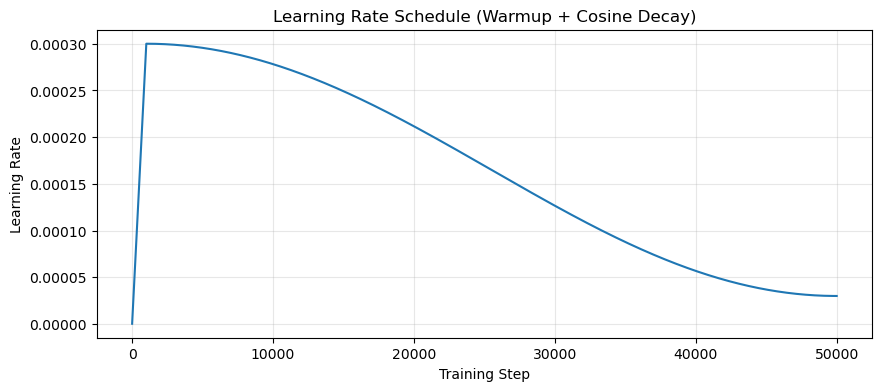

In [27]:
def get_lr(step: int, warmup_steps: int, max_steps: int, max_lr: float, min_lr: float) -> float:
    """
    Learning rate schedule with linear warmup and cosine decay.
    
    Args:
        step: Current training step
        warmup_steps: Number of warmup steps
        max_steps: Total training steps
        max_lr: Peak learning rate
        min_lr: Minimum learning rate
    """
    # Linear warmup
    if step < warmup_steps:
        return max_lr * (step + 1) / warmup_steps
    
    # Cosine decay
    if step > max_steps:
        return min_lr
    
    decay_ratio = (step - warmup_steps) / (max_steps - warmup_steps)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (max_lr - min_lr)


# Visualize learning rate schedule
steps = list(range(50000))
lrs = [get_lr(s, warmup_steps=1000, max_steps=50000, max_lr=3e-4, min_lr=3e-5) for s in steps]

plt.figure(figsize=(10, 4))
plt.plot(steps, lrs)
plt.xlabel('Training Step')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule (Warmup + Cosine Decay)')
plt.grid(True, alpha=0.3)
plt.show()

### Training Configuration & Evaluation

**TrainingConfig** defines all hyperparameters:
- `batch_size`: Samples per forward pass
- `gradient_accumulation_steps`: Effective batch = batch_size × accumulation
- `max_lr` / `min_lr`: Learning rate bounds
- `warmup_steps`: Steps for LR warmup
- `eval_interval`: How often to evaluate on validation set
- `weight_decay`: L2 regularization strength
- `grad_clip`: Maximum gradient norm (prevents exploding gradients)

**evaluate()**: Computes average validation loss over `max_batches` batches.

In [ ]:
@dataclass
class TrainingConfig:
    """Training hyperparameters."""
    batch_size: int = 32
    gradient_accumulation_steps: int = 4
    max_lr: float = 3e-4
    min_lr: float = 3e-5
    warmup_steps: int = 1000
    max_steps: int = 50000
    eval_interval: int = 500
    save_interval: int = 5000
    log_interval: int = 10
    weight_decay: float = 0.1
    grad_clip: float = 1.0

    @property
    def effective_batch_size(self):
        return self.batch_size * self.gradient_accumulation_steps


@torch.no_grad()
def evaluate(model: nn.Module, dataloader: DataLoader, device: torch.device, max_batches: int = 50) -> float:
    """Evaluate model on validation set."""
    model.eval()
    total_loss = 0.0
    n_batches = 0

    for x, y in dataloader:
        if n_batches >= max_batches:
            break

        x, y = x.to(device), y.to(device)
        _, loss = model(x, y)
        total_loss += loss.item()
        n_batches += 1

    model.train()
    return total_loss / n_batches if n_batches > 0 else float('inf')


def train(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    config: TrainingConfig,
    device: torch.device,
    checkpoint_dir: Path
) -> Dict[str, List]:
    """
    Main training loop with gradient accumulation, LR scheduling, and checkpointing.

    Returns:
        Dictionary with training history (losses, learning rates, validation steps)
    """
    model.train()

    # Optimizer
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.max_lr,
        betas=(0.9, 0.95),
        weight_decay=config.weight_decay
    )

    # Training history - now includes val_steps for proper plotting
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_steps': [],  # Track which steps had validation
        'learning_rate': [],
        'step': [],
        'eval_interval': config.eval_interval  # Store for reference
    }

    # Training state
    step = 0
    best_val_loss = float('inf')
    train_iter = iter(train_loader)

    # Progress bar
    pbar = tqdm(total=config.max_steps, desc="Training")

    # Accumulated loss for logging
    running_loss = 0.0

    while step < config.max_steps:
        # Update learning rate
        lr = get_lr(step, config.warmup_steps, config.max_steps, config.max_lr, config.min_lr)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        # Gradient accumulation loop
        optimizer.zero_grad()
        accumulated_loss = 0.0

        for micro_step in range(config.gradient_accumulation_steps):
            # Get batch
            try:
                x, y = next(train_iter)
            except StopIteration:
                train_iter = iter(train_loader)
                x, y = next(train_iter)

            x, y = x.to(device), y.to(device)

            # Forward pass
            _, loss = model(x, y)
            loss = loss / config.gradient_accumulation_steps

            # Backward pass
            loss.backward()
            accumulated_loss += loss.item()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)

        # Optimizer step
        optimizer.step()

        running_loss += accumulated_loss
        step += 1

        # Logging
        if step % config.log_interval == 0:
            avg_loss = running_loss / config.log_interval
            history['train_loss'].append(avg_loss)
            history['learning_rate'].append(lr)
            history['step'].append(step)

            pbar.set_postfix({
                'loss': f'{avg_loss:.4f}',
                'lr': f'{lr:.2e}',
                'ppl': f'{math.exp(avg_loss):.2f}'
            })
            running_loss = 0.0

        # Evaluation
        if step % config.eval_interval == 0:
            val_loss = evaluate(model, val_loader, device)
            history['val_loss'].append(val_loss)
            history['val_steps'].append(step)  # Track validation step

            print(f"\n[Step {step}] Val Loss: {val_loss:.4f}, Val PPL: {math.exp(val_loss):.2f}")

            # Save best model
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save({
                    'step': step,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_loss': val_loss,
                    'config': model.config,
                }, checkpoint_dir / 'best_model.pt')
                print(f"  New best model saved!")

        # Periodic checkpoint
        if step % config.save_interval == 0:
            torch.save({
                'step': step,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'config': model.config,
            }, checkpoint_dir / f'checkpoint_{step}.pt')

        pbar.update(1)

    pbar.close()

    # Final save
    torch.save({
        'step': step,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'config': model.config,
    }, checkpoint_dir / 'final_model.pt')

    return history


In [29]:
# MLX Training Implementation
# MLX is often faster than PyTorch on Apple Silicon for both training and inference

if MLX_AVAILABLE:
    import mlx.optimizers as mlx_optim

    def train_mlx(
        model: 'MLXGPT',
        train_texts: List[str],
        val_texts: List[str],
        tokenizer: TinyStoriesTokenizer,
        config: TrainingConfig,
        checkpoint_dir: Path,
    ) -> Dict[str, List]:
        """MLX training loop (next-token prediction).

        Notes:
          - Uses `mlx_nn.value_and_grad` for gradients.
          - Keeps the step function uncompiled for simplicity/compatibility.
          - Saves best weights to `best_mlx_model.safetensors`.
        """

        def loss_fn(m: 'MLXGPT', x: mx.array, y: mx.array) -> mx.array:
            logits = m(x)
            logits = logits.reshape(-1, logits.shape[-1])
            yy = y.reshape(-1)
            return mx.mean(mlx_nn.losses.cross_entropy(logits, yy))

        loss_and_grad = mlx_nn.value_and_grad(model, loss_fn)

        optimizer = mlx_optim.AdamW(
            learning_rate=config.max_lr,
            betas=[0.9, 0.95],
            weight_decay=config.weight_decay,
        )

        print('Tokenizing training data for MLX...')
        train_tokens = [tokenizer.encode(t, add_eos=True) for t in tqdm(train_texts)]
        val_tokens = [tokenizer.encode(t, add_eos=True) for t in tqdm(val_texts)]

        history = {
            'train_loss': [],
            'val_loss': [],
            'val_steps': [],
            'learning_rate': [],
            'step': [],
            'eval_interval': config.eval_interval,
        }

        def get_batch(tokens_list: List[List[int]], batch_size: int, block_size: int) -> Tuple[mx.array, mx.array]:
            # Randomly select sequences
            idxs = np.random.randint(0, len(tokens_list), batch_size)
            batch = []
            for i in idxs:
                toks = tokens_list[i]
                if len(toks) > block_size + 1:
                    start = np.random.randint(0, len(toks) - block_size - 1)
                    toks = toks[start:start + block_size + 1]
                else:
                    toks = toks + [tokenizer.pad_token_id] * (block_size + 1 - len(toks))
                batch.append(toks[:block_size + 1])

            arr = np.array(batch, dtype=np.int64)
            x = mx.array(arr[:, :-1])
            y = mx.array(arr[:, 1:])
            return x, y

        def eval_val_loss(num_batches: int = 25) -> float:
            losses = []
            for _ in range(num_batches):
                vx, vy = get_batch(val_tokens, config.batch_size, model.config.block_size)
                vloss = loss_fn(model, vx, vy)
                mx.eval(vloss)
                losses.append(vloss.item())
            return float(np.mean(losses)) if losses else float('nan')

        step = 0
        best_val = float('inf')
        running_loss = 0.0
        pbar = tqdm(total=config.max_steps, desc='MLX Training')

        while step < config.max_steps:
            lr = get_lr(step, config.warmup_steps, config.max_steps, config.max_lr, config.min_lr)
            optimizer.learning_rate = lr

            x, y = get_batch(train_tokens, config.batch_size, model.config.block_size)
            loss, grads = loss_and_grad(model, x, y)
            optimizer.update(model, grads)
            mx.eval(loss)

            running_loss += loss.item()
            step += 1

            if step % config.log_interval == 0:
                avg = running_loss / config.log_interval
                history['train_loss'].append(avg)
                history['learning_rate'].append(lr)
                history['step'].append(step)
                pbar.set_postfix({'loss': f'{avg:.4f}', 'lr': f'{lr:.2e}', 'ppl': f'{math.exp(avg):.2f}'})
                running_loss = 0.0

            if step % config.eval_interval == 0:
                val_loss = eval_val_loss(num_batches=min(25, max(1, len(val_tokens) // max(1, config.batch_size))))
                history['val_loss'].append(val_loss)
                history['val_steps'].append(step)
                print(f"\n[Step {step}] Val Loss: {val_loss:.4f}, Val PPL: {math.exp(val_loss):.2f}")

                if val_loss < best_val:
                    best_val = val_loss
                    model.save_weights(str(checkpoint_dir / 'best_mlx_model.safetensors'))
                    print('  New best MLX model saved!')

            if step % config.save_interval == 0:
                model.save_weights(str(checkpoint_dir / f'mlx_checkpoint_{step}.safetensors'))

            pbar.update(1)

        pbar.close()
        return history
else:
    print('MLX not available - skipping MLX training implementation')


In [30]:
# Framework selection helper
def select_training_framework() -> str:
    """Resolve which framework to use based on TRAINING_FRAMEWORK.

    TRAINING_FRAMEWORK values:
      - 'mlx'     : force MLX (requires MLX_AVAILABLE)
      - 'pytorch' : force PyTorch
      - 'auto'    : prefer MLX when available, else PyTorch
    """
    preferred = globals().get('TRAINING_FRAMEWORK', 'auto')
    if preferred is None:
        preferred = 'auto'
    preferred = str(preferred).strip().lower()

    if preferred not in {'auto', 'mlx', 'pytorch'}:
        raise ValueError(f"Invalid TRAINING_FRAMEWORK={preferred!r}. Use 'auto', 'mlx', or 'pytorch'.")

    if preferred == 'pytorch':
        print('Training framework selected: pytorch')
        return 'pytorch'

    if preferred == 'mlx':
        if not MLX_AVAILABLE:
            raise RuntimeError("TRAINING_FRAMEWORK='mlx' but MLX is not available.")
        print('Training framework selected: mlx')
        return 'mlx'

    # auto
    if MLX_AVAILABLE:
        print('Training framework selected: mlx (auto)')
        return 'mlx'

    print('Training framework selected: pytorch (auto; MLX unavailable)')
    return 'pytorch'


---
# Part 6: PyTorch MPS vs MLX Comparison

Benchmark both frameworks on the same model architecture to compare performance.

### PyTorch Benchmark

Measures model performance on MPS (Metal Performance Shaders):
- **Forward pass latency**: Time to compute logits
- **Backward pass latency**: Time to compute gradients
- **Throughput**: Tokens per second

Results are averaged over multiple iterations for stability.

In [31]:
def benchmark_pytorch(model: nn.Module, batch_size: int, seq_len: int, device: torch.device, n_iterations: int = 100):
    """Benchmark PyTorch model forward and backward pass."""
    model.train()
    
    # Warmup
    x = torch.randint(0, model.config.vocab_size, (batch_size, seq_len), device=device)
    y = torch.randint(0, model.config.vocab_size, (batch_size, seq_len), device=device)
    
    for _ in range(10):
        _, loss = model(x, y)
        loss.backward()
    
    if device.type == 'mps':
        torch.mps.synchronize()
    
    # Forward pass benchmark
    forward_times = []
    for _ in range(n_iterations):
        x = torch.randint(0, model.config.vocab_size, (batch_size, seq_len), device=device)
        
        start = time.perf_counter()
        with torch.no_grad():
            logits, _ = model(x)
        if device.type == 'mps':
            torch.mps.synchronize()
        forward_times.append(time.perf_counter() - start)
    
    # Backward pass benchmark
    backward_times = []
    for _ in range(n_iterations):
        x = torch.randint(0, model.config.vocab_size, (batch_size, seq_len), device=device)
        y = torch.randint(0, model.config.vocab_size, (batch_size, seq_len), device=device)
        
        start = time.perf_counter()
        _, loss = model(x, y)
        loss.backward()
        if device.type == 'mps':
            torch.mps.synchronize()
        backward_times.append(time.perf_counter() - start)
        
        model.zero_grad()
    
    tokens_per_batch = batch_size * seq_len
    
    return {
        'forward_ms': np.mean(forward_times) * 1000,
        'backward_ms': np.mean(backward_times) * 1000,
        'forward_tokens_per_sec': tokens_per_batch / np.mean(forward_times),
        'backward_tokens_per_sec': tokens_per_batch / np.mean(backward_times),
    }


def benchmark_mlx(config: GPTConfig, batch_size: int, seq_len: int, n_iterations: int = 100):
    """Benchmark MLX model forward pass."""
    if not MLX_AVAILABLE:
        return None
    
    model = MLXGPT(config)
    mx.eval(model.parameters())
    
    # Warmup
    x = mx.random.randint(0, config.vocab_size, (batch_size, seq_len))
    for _ in range(10):
        logits = model(x)
        mx.eval(logits)
    
    # Forward pass benchmark
    forward_times = []
    for _ in range(n_iterations):
        x = mx.random.randint(0, config.vocab_size, (batch_size, seq_len))
        
        start = time.perf_counter()
        logits = model(x)
        mx.eval(logits)
        forward_times.append(time.perf_counter() - start)
    
    tokens_per_batch = batch_size * seq_len
    
    return {
        'forward_ms': np.mean(forward_times) * 1000,
        'forward_tokens_per_sec': tokens_per_batch / np.mean(forward_times),
    }


# Run benchmarks
print("=" * 60)
print("Framework Comparison Benchmark")
print("=" * 60)

BENCH_BATCH_SIZE = 8
BENCH_SEQ_LEN = 256
N_ITER = 50

print(f"\nBenchmark settings:")
print(f"  Batch size: {BENCH_BATCH_SIZE}")
print(f"  Sequence length: {BENCH_SEQ_LEN}")
print(f"  Iterations: {N_ITER}")
print(f"  Tokens per batch: {BENCH_BATCH_SIZE * BENCH_SEQ_LEN:,}")

# PyTorch benchmark
print("\n--- PyTorch MPS ---")
pytorch_results = benchmark_pytorch(model, BENCH_BATCH_SIZE, BENCH_SEQ_LEN, DEVICE, N_ITER)
print(f"Forward pass: {pytorch_results['forward_ms']:.2f} ms ({pytorch_results['forward_tokens_per_sec']:.0f} tokens/s)")
print(f"Forward+Backward: {pytorch_results['backward_ms']:.2f} ms ({pytorch_results['backward_tokens_per_sec']:.0f} tokens/s)")

# MLX benchmark
if MLX_AVAILABLE:
    print("\n--- MLX ---")
    mlx_results = benchmark_mlx(config, BENCH_BATCH_SIZE, BENCH_SEQ_LEN, N_ITER)
    print(f"Forward pass: {mlx_results['forward_ms']:.2f} ms ({mlx_results['forward_tokens_per_sec']:.0f} tokens/s)")

# Comparison
if MLX_AVAILABLE:
    print("\n--- Comparison (Forward Pass) ---")
    speedup = pytorch_results['forward_ms'] / mlx_results['forward_ms']
    if speedup > 1:
        print(f"MLX is {speedup:.2f}x faster than PyTorch MPS")
    else:
        print(f"PyTorch MPS is {1/speedup:.2f}x faster than MLX")

Framework Comparison Benchmark

Benchmark settings:
  Batch size: 8
  Sequence length: 256
  Iterations: 50
  Tokens per batch: 2,048

--- PyTorch MPS ---
Forward pass: 22.23 ms (92137 tokens/s)
Forward+Backward: 57.36 ms (35701 tokens/s)

--- MLX ---
Forward pass: 15.37 ms (133243 tokens/s)

--- Comparison (Forward Pass) ---
MLX is 1.45x faster than PyTorch MPS


---
# Part 7: Evaluation & Generation

This section covers:
1. Loss curves visualization
2. Text generation with various sampling methods
3. Attention visualization

### Training Visualization

`plot_training_history()` creates two plots:
1. **Loss Curves**: Training and validation loss over steps
2. **Learning Rate**: LR schedule visualization

Also prints final metrics: loss and perplexity (exp(loss)).

In [32]:
def plot_training_history(history: Dict[str, List], eval_interval: int = None):
    """Plot training and validation loss curves.

    Args:
        history: Dictionary containing training history with keys:
            - step: Training step numbers
            - train_loss: Training loss values
            - val_loss: Validation loss values
            - learning_rate: Learning rate values
            - val_steps: (optional) Steps at which validation was performed
        eval_interval: Evaluation interval used during training. Only needed if
            val_steps is not in history.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curves
    steps = history['step']
    train_loss = history['train_loss']

    axes[0].plot(steps, train_loss, label='Train Loss', alpha=0.7)

    # Plot validation loss at eval intervals
    if history['val_loss']:
        # Use stored val_steps if available, otherwise calculate from eval_interval
        if 'val_steps' in history and history['val_steps']:
            val_steps = history['val_steps']
        elif eval_interval is not None:
            # Calculate validation steps from eval_interval
            val_steps = list(range(eval_interval, len(history['val_loss']) * eval_interval + 1, eval_interval))
            val_steps = val_steps[:len(history['val_loss'])]
        else:
            # Fallback: try to infer from step list
            # Find steps that could be eval points (evenly spaced)
            n_vals = len(history['val_loss'])
            if n_vals > 0 and len(steps) > 0:
                # Assume validation happens at regular intervals
                max_step = max(steps)
                inferred_interval = max_step // n_vals if n_vals > 0 else 500
                val_steps = list(range(inferred_interval, max_step + 1, inferred_interval))[:n_vals]
            else:
                val_steps = list(range(len(history['val_loss'])))

        axes[0].plot(val_steps, history['val_loss'], label='Val Loss', marker='o', markersize=4)

    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training & Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Learning rate
    axes[1].plot(steps, history['learning_rate'])
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Learning Rate')
    axes[1].set_title('Learning Rate Schedule')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print final metrics
    if train_loss:
        print(f"\nFinal Training Loss: {train_loss[-1]:.4f}")
        print(f"Final Training Perplexity: {math.exp(train_loss[-1]):.2f}")
    if history['val_loss']:
        print(f"Best Validation Loss: {min(history['val_loss']):.4f}")
        print(f"Best Validation Perplexity: {math.exp(min(history['val_loss'])):.2f}")


### Text Generation

**generate_text()** implements autoregressive generation with configurable sampling:

- **Temperature**: Controls randomness (lower = more deterministic)
- **Top-k**: Only sample from k most likely tokens
- **Top-p (Nucleus)**: Sample from smallest set with cumulative probability ≥ p

**interactive_generation()** provides a loop for testing prompts interactively.

In [33]:
def generate_text_pytorch(
    model: nn.Module,
    tokenizer: TinyStoriesTokenizer,
    prompt: str,
    max_new_tokens: int = 200,
    temperature: float = 0.8,
    top_k: int = 50,
    top_p: float = 0.9,
    device: torch.device = DEVICE,
) -> str:
    """Generate text using the PyTorch GPT model."""
    model.eval()

    tokens = tokenizer.encode(prompt, add_eos=False)
    idx = torch.tensor([tokens], dtype=torch.long, device=device)

    with torch.no_grad():
        generated = model.generate(
            idx,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            eos_token_id=tokenizer.eos_token_id,
        )

    generated_tokens = generated[0].tolist()
    return tokenizer.decode(generated_tokens)


def _sample_next_token_mlx(
    logits: 'mx.array',
    top_k: int = 50,
    top_p: float = 0.9,
) -> 'mx.array':
    """Sample next token IDs from logits (B, V) using top-k and/or top-p."""
    B, V = logits.shape

    def _nucleus_sample(sorted_logits: 'mx.array', sorted_indices: 'mx.array') -> 'mx.array':
        probs = mx.softmax(sorted_logits, axis=-1)
        if top_p is not None:
            cum = mx.cumsum(probs, axis=-1)
            remove = cum > top_p
            # shift right so we always keep at least 1 token
            false_col = mx.full((B, 1), False, dtype=remove.dtype)
            remove = mx.concatenate([false_col, remove[:, :-1]], axis=-1)
            probs = mx.where(remove, 0.0, probs)
            probs = probs / mx.sum(probs, axis=-1, keepdims=True)

        # categorical expects log-probs
        choice_pos = mx.random.categorical(mx.log(probs + 1e-20))
        next_id = mx.take_along_axis(sorted_indices, choice_pos[:, None], axis=-1)
        return next_id

    if top_k is not None:
        k = int(min(top_k, V))
        sorted_idx = mx.argsort(logits, axis=-1)[:, ::-1]
        topk_idx = sorted_idx[:, :k]
        topk_logits = mx.take_along_axis(logits, topk_idx, axis=-1)
        return _nucleus_sample(topk_logits, topk_idx)

    # top_p only (use full vocab)
    sorted_idx = mx.argsort(logits, axis=-1)[:, ::-1]
    sorted_logits = mx.take_along_axis(logits, sorted_idx, axis=-1)
    return _nucleus_sample(sorted_logits, sorted_idx)


def generate_text_mlx(
    model: 'MLXGPT',
    tokenizer: TinyStoriesTokenizer,
    prompt: str,
    max_new_tokens: int = 200,
    temperature: float = 0.8,
    top_k: int = 50,
    top_p: float = 0.9,
    eos_token_id=None,
) -> str:
    """Generate text using the MLX GPT model."""
    if not MLX_AVAILABLE:
        raise RuntimeError("MLX is not available, cannot run MLX generation")

    import numpy as _np

    # Encode prompt
    tokens = tokenizer.encode(prompt, add_eos=False)
    idx = mx.array([tokens])

    eos = tokenizer.eos_token_id if eos_token_id is None else eos_token_id

    for _ in range(max_new_tokens):
        # Crop to block size if needed
        if idx.shape[1] > model.config.block_size:
            idx_cond = idx[:, -model.config.block_size:]
        else:
            idx_cond = idx

        logits = model(idx_cond)
        logits = logits[:, -1, :] / temperature

        idx_next = _sample_next_token_mlx(logits, top_k=top_k, top_p=top_p)
        idx = mx.concatenate([idx, idx_next], axis=1)

        # Force evaluation each iteration to avoid building a huge lazy graph
        mx.eval(idx)

        # Stop on EOS
        next_id = int(_np.array(idx_next)[0, 0])
        if eos is not None and next_id == eos:
            break

    generated_tokens = _np.array(idx)[0].tolist()
    return tokenizer.decode(generated_tokens)


def generate_text(
    model,
    tokenizer: TinyStoriesTokenizer,
    prompt: str,
    max_new_tokens: int = 200,
    temperature: float = 0.8,
    top_k: int = 50,
    top_p: float = 0.9,
    device: torch.device = DEVICE,
) -> str:
    """Framework-agnostic generation wrapper (PyTorch or MLX)."""
    if isinstance(model, nn.Module):
        return generate_text_pytorch(
            model=model,
            tokenizer=tokenizer,
            prompt=prompt,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            device=device,
        )

    if MLX_AVAILABLE and 'mlx_nn' in globals() and isinstance(model, mlx_nn.Module):
        return generate_text_mlx(
            model=model,
            tokenizer=tokenizer,
            prompt=prompt,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
        )

    raise TypeError(f"Unsupported model type for generate_text(): {type(model)}")


def interactive_generation(model, tokenizer: TinyStoriesTokenizer):
    """Interactive text generation demo."""
    print("=" * 60)
    print("Interactive Story Generation")
    print("=" * 60)
    print("Enter a prompt to generate a story. Type 'quit' to exit.")
    print("Tip: Try starting with 'Once upon a time' or character names")
    print()

    while True:
        try:
            prompt = input("Prompt: ").strip()
        except Exception as e:
            print()
            print(f"Interactive input not supported in this environment: {e}")
            print("Use generate_text(model, tokenizer, prompt=...) instead.")
            break

        if prompt.lower() == 'quit':
            break

        if not prompt:
            prompt = "Once upon a time"
            print(f"Using default prompt: '{prompt}'")

        print()
        print("Generating...")
        print("-" * 40)

        text = generate_text(model, tokenizer, prompt, max_new_tokens=200)
        print(text)

        print("-" * 40)
        print()


# Demo generation (without trained model - will produce random text)
print("Demo generation with untrained model:")
print("(Expected: random/nonsensical text since model isn't trained yet)")
print()

demo_prompt = "Once upon a time, there was a"
print(f"Prompt: '{demo_prompt}'")
print("-" * 40)

if MLX_AVAILABLE:
    demo_model = MLXGPT(config)
    print("(Using MLX model for demo generation)")
else:
    demo_model = model  # falls back to the PyTorch model created earlier in the notebook
    print("(Using PyTorch model for demo generation)")

print()
generated = generate_text(demo_model, tok, demo_prompt, max_new_tokens=100, temperature=0.8)
print(generated)
print("-" * 40)


Demo generation with untrained model:
(Expected: random/nonsensical text since model isn't trained yet)

Prompt: 'Once upon a time, there was a'
----------------------------------------
(Using MLX model for demo generation)

Once upon a time, there was aels antic tokensey toursety voice voice noon nightmares windyhna cheerfulility posters underneath yan nightmares instin?'. noon delivery circledorm houseIt ignorant instin noon tags fizz spoon miller offers overhe nighttimerigued steering classrooms nightmaresAn Wherever You by by You steering miller wiggling fizz threatening delivery admiringuggled outrun offersandihna shallow outrun offers delivery cooperative convincedTerryIt adultsasant ropes stitching recognisedœDaddyelery posters steeringreed?'. Pepper classrooms threatening brothers? Thump Fllowly encl steering willing classrooms? steeringriana steering offers delivery? delivery Noah pricesœDaddy
----------------------------------------


---
# Part 8: Putting It All Together

This section provides:
1. Quick training on a small subset (for testing)
2. Full training configuration
3. Model loading and inference

### Quick Training Test

This cell runs a **rapid validation** of the entire pipeline:
- Uses small data subset (5000 train, 500 val samples)
- Trains for only 200 steps
- Verifies loss decreases and generation works

Run this before full training to catch configuration errors early.

In [37]:
# Quick test training on small subset
# This verifies everything works before full training

QUICK_TEST = True  # Set to False for full training

# Choose framework (defaults to MLX when available)
TRAINING_FRAMEWORK_SELECTED = select_training_framework()

if QUICK_TEST:
    print("=" * 60)
    print("QUICK TEST MODE")
    print("Training on small subset to verify setup")
    print(f"Framework: {TRAINING_FRAMEWORK_SELECTED}")
    print("=" * 60)

    # Use small subset
    test_train_texts = train_texts[:5000]
    test_val_texts = val_texts[:500]

    if TRAINING_FRAMEWORK_SELECTED == "mlx":
        if not MLX_AVAILABLE:
            raise RuntimeError("TRAINING_FRAMEWORK='mlx' but MLX is not available")

        # Guard: user may run this cell without running the MLX training implementation cell
        if 'train_mlx' not in globals():
            raise NameError("train_mlx is not defined. Run the 'MLX Training Implementation' cell (Part 5: Training Pipeline) before running this quick test.")

        # MLX quick training config (note: current train_mlx does not implement grad accumulation)
        quick_config = TrainingConfig(
            batch_size=16,
            gradient_accumulation_steps=1,
            max_lr=3e-4,
            min_lr=3e-5,
            warmup_steps=50,
            max_steps=200,
            eval_interval=50,
            save_interval=100,
            log_interval=10,
        )

        print()
        print("Training config:")
        print(f"  Batch size: {quick_config.batch_size}")
        print(f"  Gradient accumulation: {quick_config.gradient_accumulation_steps} (not yet used in MLX loop)")
        print(f"  Max steps: {quick_config.max_steps}")

        print()
        print("Creating MLX model...")
        model = MLXGPT(config)
        mx.eval(model.parameters())

        print()
        print("Starting MLX training...")
        history = train_mlx(
            model=model,
            train_texts=test_train_texts,
            val_texts=test_val_texts,
            tokenizer=tok,
            config=quick_config,
            checkpoint_dir=CHECKPOINTS_DIR,
        )

    else:
        # PyTorch quick training path (fallback)
        quick_config = TrainingConfig(
            batch_size=16,
            gradient_accumulation_steps=2,
            max_lr=3e-4,
            min_lr=3e-5,
            warmup_steps=50,
            max_steps=200,
            eval_interval=50,
            save_interval=100,
            log_interval=10,
        )

        print()
        print("Training config:")
        print(f"  Batch size: {quick_config.batch_size}")
        print(f"  Gradient accumulation: {quick_config.gradient_accumulation_steps}")
        print(f"  Effective batch size: {quick_config.effective_batch_size}")
        print(f"  Max steps: {quick_config.max_steps}")

        print()
        print("Creating PyTorch model...")
        model = GPT(config)
        model = model.to(DEVICE)

        print()
        print("Preparing data...")
        train_loader, val_loader = create_dataloaders(
            test_train_texts,
            test_val_texts,
            tok,
            config.block_size,
            quick_config.batch_size,
        )

        print()
        print("Starting PyTorch training...")
        history = train(
            model,
            train_loader,
            val_loader,
            quick_config,
            DEVICE,
            CHECKPOINTS_DIR,
        )

    # Keep a consistent name for later inference cells
    trained_model = model

    # Plot results
    plot_training_history(history, eval_interval=quick_config.eval_interval)

    # Generate sample
    print()
    print("=" * 60)
    print("Sample Generation After Quick Training")
    print("=" * 60)

    prompts = [
        "Once upon a time",
        "The little boy",
        "She was very happy because",
    ]

    for prompt in prompts:
        print()
        print(f"Prompt: '{prompt}'")
        print("-" * 40)
        text = generate_text(trained_model, tok, prompt, max_new_tokens=100, temperature=0.8)
        print(text)
        print("-" * 40)
else:
    print("Quick test skipped. Set QUICK_TEST = True to run.")


Training framework selected: mlx
QUICK TEST MODE
Training on small subset to verify setup
Framework: mlx

Training config:
  Batch size: 16
  Gradient accumulation: 1 (not yet used in MLX loop)
  Max steps: 200

Creating MLX model...

Starting MLX training...
Tokenizing training data for MLX...


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

MLX Training:   0%|          | 0/200 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Full Training Configuration

Uncomment this cell to run complete training on TinyStories:
- 50,000+ steps for meaningful convergence
- Checkpoints saved every 5,000 steps
- Best model saved when validation loss improves

**Estimated time on M4 Max**: 4-8 hours for full training.

In [ ]:
# FULL TRAINING
# Uncomment and run this cell for complete training on TinyStories

"""
# Full training configuration
full_config = TrainingConfig(
    batch_size=32,
    gradient_accumulation_steps=4,
    max_lr=3e-4,
    min_lr=3e-5,
    warmup_steps=1000,
    max_steps=50000,  # Adjust based on desired training time
    eval_interval=500,
    save_interval=5000,
    log_interval=10,
)

print("=" * 60)
print("FULL TRAINING MODE")
print("=" * 60)
print(f"Effective batch size: {full_config.effective_batch_size}")
print(f"Max steps: {full_config.max_steps}")
print(f"Estimated total tokens: {full_config.max_steps * full_config.effective_batch_size * config.block_size:,}")

# Create fresh model
model = MLXGPT(config)
mx.eval(model.parameters())

# Create dataloaders (full dataset)
print("\nPreparing full dataset (this may take several minutes)...")
# NOTE: MLX training uses tokenized text lists directly; no PyTorch DataLoader needed

# Train
print("\nStarting full training...")
print("This will take several hours on M4 Max.")
print("Progress will be saved to checkpoints every 5000 steps.")

history = train_mlx(
    model=model,
    train_texts=train_texts,
    val_texts=val_texts,
    tokenizer=tok,
    config=full_config,
    checkpoint_dir=CHECKPOINTS_DIR
)

# Save final results
plot_training_history(history)

# Save history
with open(CHECKPOINTS_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f)
print(f"Training history saved to {CHECKPOINTS_DIR / 'training_history.json'}")
"""

print("Full training code is commented out.")
print("Uncomment the cell above to run full training.")
print(f"\nEstimated training time on M4 Max (48GB):")
print(f"  10K steps: ~1-2 hours")
print(f"  50K steps: ~4-8 hours")
print(f"  100K steps: ~8-16 hours")

### Model Loading

`load_model()` restores a trained model from checkpoint:
- Automatically loads model configuration
- Compatible with PyTorch 2.6+ (uses safe globals)
- Returns model in eval mode, ready for inference

### Interactive Inference

`run_interactive_inference()` provides a user-friendly generation interface:
- Enter custom prompts or select from examples
- Configurable generation parameters
- Type 'quit' to exit

**Example prompts to try**:
- "Once upon a time, there was a little"
- "The brave knight set out on a journey to"
- "In a magical forest, a small rabbit named"

In [ ]:
# ============================================================
# Interactive Inference Cell
# ============================================================
# This cell provides a user-friendly interface for testing the trained model

from pathlib import Path

# MLX loader (safetensors produced by train_mlx)
if MLX_AVAILABLE:
    def load_mlx_model(weights_path: str, config: GPTConfig) -> 'MLXGPT':
        """Load MLX model weights from a .safetensors file."""
        model = MLXGPT(config)
        model.load_weights(weights_path)
        mx.eval(model.parameters())
        print(f"Loaded MLX model weights from: {weights_path}")
        return model


def run_interactive_inference(model, tokenizer, device=DEVICE):
    """Interactive text generation with configurable parameters."""
    print("=" * 60)
    print("Interactive Story Generation")
    print("=" * 60)
    print()
    print("Generation Parameters:")
    print("-" * 40)

    # Configurable generation parameters
    temperature = 0.8
    top_k = 50
    top_p = 0.9
    max_tokens = 200

    print(f"  Temperature: {temperature} (creativity vs focus)")
    print(f"  Top-k: {top_k} (vocabulary diversity)")
    print(f"  Top-p: {top_p} (nucleus sampling)")
    print(f"  Max tokens: {max_tokens}")

    example_prompts = [
        "Once upon a time, there was a little",
        "The brave knight set out on a journey to",
        "In a magical forest, a small rabbit named",
        "One sunny day, a curious cat decided to",
        "The princess looked out her window and saw",
    ]

    print()
    print("=" * 60)
    print("Example prompts you can try:")
    print("=" * 60)
    for i, prompt in enumerate(example_prompts, 1):
        print(f"  {i}. {prompt}")

    print()
    print("=" * 60)
    print("Enter 'quit' to exit, or press Enter for a random example")
    print("=" * 60)

    while True:
        print()
        try:
            user_input = input("Your prompt: ").strip()
        except Exception as e:
            print()
            print(f"Interactive input not supported in this environment: {e}")
            print("Use quick_generate(prompt=...) instead.")
            break

        if user_input.lower() == 'quit':
            print()
            print("Goodbye!")
            break

        if not user_input:
            import random
            prompt = random.choice(example_prompts)
            print(f"Using example: '{prompt}'")
        elif user_input.isdigit() and 1 <= int(user_input) <= len(example_prompts):
            prompt = example_prompts[int(user_input) - 1]
            print(f"Using: '{prompt}'")
        else:
            prompt = user_input

        print()
        print("Generating...", flush=True)

        generated = generate_text(
            model=model,
            tokenizer=tokenizer,
            prompt=prompt,
            max_new_tokens=max_tokens,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            device=device,
        )

        print()
        print("=" * 60)
        print("Generated Story:")
        print("=" * 60)
        print(generated)
        print("=" * 60)


def quick_generate(prompt: str, max_tokens: int = 150, temperature: float = 0.8):
    """Quick generation helper for notebook cells."""
    if 'trained_model' not in dir() or trained_model is None:
        print("Error: No trained model available. Run training first or load a checkpoint.")
        return None

    return generate_text(
        model=trained_model,
        tokenizer=tok,
        prompt=prompt,
        max_new_tokens=max_tokens,
        temperature=temperature,
    )


# Load a trained model for interactive inference
TRAINING_FRAMEWORK_SELECTED = select_training_framework()

if TRAINING_FRAMEWORK_SELECTED == 'mlx':
    mlx_path = CHECKPOINTS_DIR / 'best_mlx_model.safetensors'
    if Path(mlx_path).exists():
        trained_model = load_mlx_model(str(mlx_path), config)
    else:
        print(f"MLX checkpoint not found at {mlx_path}. Falling back to PyTorch checkpoint.")
        trained_model = load_model(str(CHECKPOINTS_DIR / 'best_model.pt'))
else:
    trained_model = load_model(str(CHECKPOINTS_DIR / 'best_model.pt'))

run_interactive_inference(trained_model, tok)

print("Interactive inference functions defined:")
print("  - run_interactive_inference(model, tokenizer)")
print("  - quick_generate(prompt, max_tokens, temperature)")


Training framework selected: mlx
Loaded MLX model weights from: /Users/every1/Desktop/local_llm_testing/local_llm_training/models/checkpoints/best_mlx_model.safetensors
Interactive Story Generation

Generation Parameters:
----------------------------------------
  Temperature: 0.8 (creativity vs focus)
  Top-k: 50 (vocabulary diversity)
  Top-p: 0.9 (nucleus sampling)
  Max tokens: 200

Example prompts you can try:
  1. Once upon a time, there was a little
  2. The brave knight set out on a journey to
  3. In a magical forest, a small rabbit named
  4. One sunny day, a curious cat decided to
  5. The princess looked out her window and saw

Enter 'quit' to exit, or press Enter for a random example



Your prompt:  there was a little girl named Ana



Generating...

Generated Story:
there was a little girl named Ana, was so happy. She had a big, a big park and wanted to play with a big, she it. 


The, but it and they a big, so excited. "I!"





But put her, " said, but to play. She came. He could the car. The little boy was so happy to a a toy, and smiled and felt a big, but the, the ground to make a big friends.



---
# Summary

## What We Built

This notebook implemented a complete language model training pipeline from scratch:

1. **Environment Setup**: Verified PyTorch MPS and MLX availability on Apple Silicon
2. **Dataset**: Loaded and explored the TinyStories dataset (2.1M+ stories)
3. **Tokenization**:
   - Educational BPE implementation from scratch
   - Production tokenizer using HuggingFace tokenizers
4. **Model Architecture**: GPT-style transformer with ~34M parameters (default config; scalable to ~60M+)
   - Token and positional embeddings
   - Multi-head causal self-attention (with Flash Attention support)
   - Feed-forward networks with GELU activation
   - Pre-norm transformer blocks
5. **Training Pipeline**:
   - Gradient accumulation
   - Learning rate scheduling (warmup + cosine decay)
   - Gradient clipping
   - Checkpointing
6. **Framework Comparison**: Benchmarked PyTorch MPS vs MLX
7. **Generation**: Temperature, top-k, and top-p sampling

## Model Configuration

| Parameter | Value |
|-----------|-------|
| Vocabulary Size | 16,384 |
| Context Length | 512 |
| Embedding Dim | 512 |
| Attention Heads | 8 |
| Layers | 8 |
| Total Parameters | ~34M (default config) |

## Next Steps

1. **Run full training**: Uncomment the full training cell and let it run for several hours
2. **Experiment with hyperparameters**: Try different learning rates, model sizes, etc.
3. **Try larger models**: Increase layers/embedding dim (monitor memory usage)
4. **Fine-tune on specific data**: Adapt the model for different story styles
5. **Export for inference**: Optimize the model for deployment

## Resources

- [Sebastian Raschka's LLMs-from-scratch](https://github.com/rasbt/LLMs-from-scratch)
- [Karpathy's nanoGPT](https://github.com/karpathy/nanoGPT)
- [Karpathy's minbpe](https://github.com/karpathy/minbpe)
- [TinyStories Paper](https://arxiv.org/abs/2305.07759)
- [Apple MLX Documentation](https://ml-explore.github.io/mlx/)